# Masking cloud and land over water, without labels

*Turning cloud detection into a regression problem: predict the infrared bands from the
visible ones, and the pixels that break the relationship are the ones to throw away. The same
fit, read through its residual, doubles as an anomaly detector.*

Cloud masking over water is not the solved problem it is over land. Fmask and s2cloudless
are built for terrestrial scenes and degrade over water, where thin cirrus, sun glint and
the sea surface overlap spectrally, the very case a reef study is made of. 

Everything here runs on **Level-1C top-of-atmosphere reflectance**, deliberately. L2A
surface reflectance is produced by an algorithm that estimates the atmosphere from dark
*vegetation*, an assumption that is difficult to test whether it accurately applies on water; the artefacts it introduces are scene-dependent and therefore may create issues in long time series comparison. L1C is less corrected but consistent, which is the property that matters across an archive, particularly for ML applications.

**The data.** `reef_cloudy.npy` is one reef clipped from a Sentinel-2 L1C scene over tile
55LCD (2016-03-23): 604×598 pixels at 10 m, all 13 MSI bands in native order B01…B12,
stored as ESA delivers them (DN ~ reflectance × 10 000).

604x598 pixels, 13 bands, reflectance 0.000–0.789


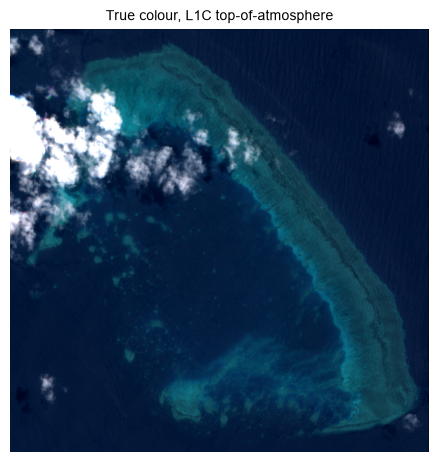

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from matplotlib.patches import Patch, Rectangle

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
})

# Sentinel-2 MSI band order in the cube: B01 B02 B03 B04 B05 B06 B07 B08 B8A B09 B10 B11 B12
BLUE, GREEN, RED, NIR = 1, 2, 3, 7
PENETRATING = [BLUE, GREEN, RED, NIR]  # reach into or through the water column
INFRARED = [9, 10, 11, 12]             # B09 water vapour, B10 cirrus, B11/B12 SWIR

reef = np.load("../data/reef_cloudy.npy").astype(np.float32) / 10000.0
print(f"{reef.shape[0]}x{reef.shape[1]} pixels, {reef.shape[2]} bands, "
      f"reflectance {reef.min():.3f}–{reef.max():.3f}")


def stretch(img, low=2, high=98):
    """Percentile stretch to [0, 1] for display only."""
    lo, hi = np.nanpercentile(img, [low, high])
    return np.clip((img - lo) / (hi - lo), 0, 1)


rgb = stretch(reef[:, :, [RED, GREEN, BLUE]])
plt.figure(figsize=(5.5, 5.5))
plt.imshow(rgb)
plt.title("True colour, L1C top-of-atmosphere")
plt.axis("off")
plt.show()

## Learning the visible-to-infrared relationship

The physics is one sentence: **water absorbs infrared almost completely, and clouds and
land do not.** Concretely, the eight bands involved split by how far each wavelength
survives under water:

| band | centre | survives under water | role |
|---|---|---|---|
| B02 blue | 490 nm | ~20 m | input |
| B03 green | 560 nm | ~15 m | input |
| B04 red | 665 nm | ~5 m | input |
| B08 near-infrared | 842 nm | <1 m | input |
| B09 water vapour | 945 nm | ≈ 0 — absorbed at the surface | target |
| B10 cirrus | 1375 nm | ≈ 0 | target |
| B11 SWIR | 1610 nm | ≈ 0 | target |
| B12 SWIR | 2190 nm | ≈ 0 | target |

So a clear water pixel obeys a predictable relationship, some visible
reflectance from the water column and the bottom, essentially zero infrared. Cloud and
land break it by being bright in both.

The usual way to exploit this is a hand built index with crafted thresholds, or a
classifier trained on labelled cloud masks. Neither is necessary. Fit a regressor from
the four water-penetrating bands to the mean of the four infrared bands and the
relationship comes straight out of the data, the same idea NDVI plays with fixed
coefficients, except the coefficients are estimated rather than assumed, and no pixel was
ever labelled "cloud".

Framing it as regression rather than classification is what removes the labels. There is
no ground truth to collect: the target variable is four bands that were sitting in the
product all along.

In [4]:
pixels = reef.reshape(-1, reef.shape[2])

model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.3, n_jobs=-1)
model.fit(pixels[:, PENETRATING], pixels[:, INFRARED].mean(axis=1))

predicted_ir = model.predict(pixels[:, PENETRATING]).reshape(reef.shape[:2])
actual_ir = reef[:, :, INFRARED].mean(axis=2)
print(f"mean absolute error: {np.abs(predicted_ir - actual_ir).mean() * 10000:.0f} DN")

mean absolute error: 13 DN


One threshold turns the prediction into a mask, and it is the only subjective number in
the whole workflow. The histogram makes the choice easy rather than arbitrary: water and
not-water are two separated populations, and 0.03 reflectance sits in the empty valley
between them.

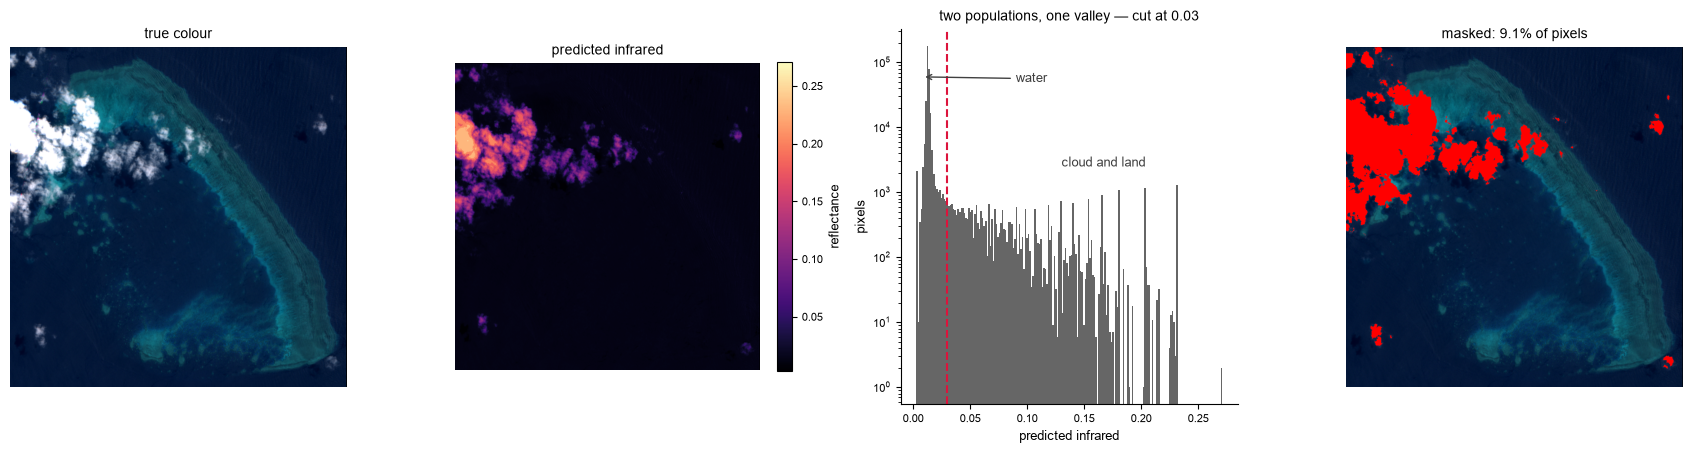

In [5]:
water = predicted_ir < 0.03

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
axes[0].imshow(rgb); axes[0].set_title("true colour")
im = axes[1].imshow(predicted_ir, cmap="magma"); axes[1].set_title("predicted infrared")
plt.colorbar(im, ax=axes[1], fraction=0.046, label="reflectance")
axes[2].hist(predicted_ir.ravel(), bins=200, log=True, color="0.4")
axes[2].axvline(0.03, color="crimson", ls="--")
axes[2].annotate("water", xy=(0.008, 6e4), xytext=(0.09, 5e4), color="0.25",
                 arrowprops=dict(arrowstyle="->", color="0.25"))
axes[2].text(0.13, 2.5e3, "cloud and land", color="0.25")
axes[2].set(title="two populations, one valley — cut at 0.03",
            xlabel="predicted infrared", ylabel="pixels")
overlay = rgb.copy(); overlay[~water] = [1, 0, 0]
axes[3].imshow(overlay); axes[3].set_title(f"masked: {(~water).mean():.1%} of pixels")
for ax in axes[[0, 1, 3]]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Comparison with a brightness threshold

What matters in that last panel is what is *not* red. The reef flat is one of the
brightest features in the scene, because the model keys on the visible-to-infrared relationship rather
than on brightness.


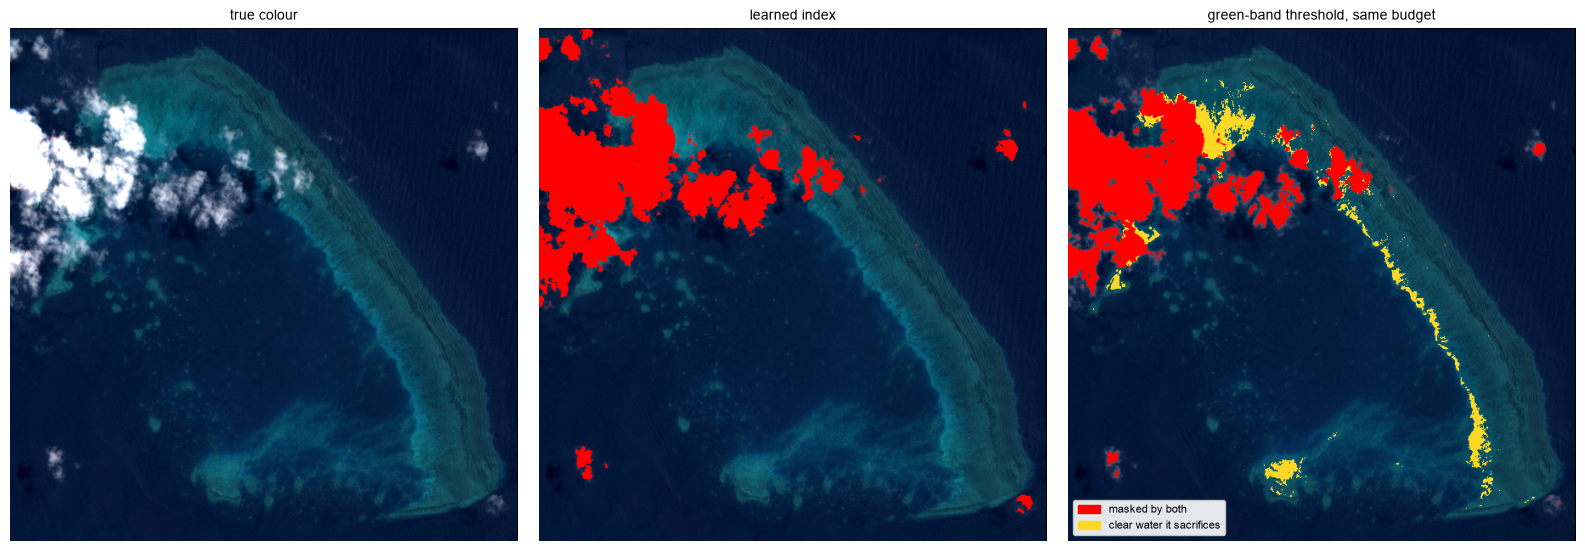

brightness cut removes 6,913 pixels the learned index keeps as clear water — 21% of everything it masks


In [7]:
cut = np.percentile(reef[:, :, GREEN], 100 * water.mean())
bright_mask = reef[:, :, GREEN] > cut          # same number of pixels masked
lost = bright_mask & water                     # clear water the brightness cut sacrifices

fig, axes = plt.subplots(1, 3, figsize=(16, 5.4))
axes[0].imshow(rgb); axes[0].set_title("true colour")
shown = rgb.copy(); shown[~water] = [1, 0, 0]
axes[1].imshow(shown); axes[1].set_title("learned index")
shown = rgb.copy()
shown[bright_mask & ~water] = [1, 0, 0]        # cloud both methods agree on
shown[lost] = [1, 0.85, 0.15]                  # the reef and water it sacrifices
axes[2].imshow(shown); axes[2].set_title("green-band threshold, same budget")
axes[2].legend(handles=[Patch(color=(1, 0, 0), label="masked by both"),
                        Patch(color=(1, 0.85, 0.15), label="clear water it sacrifices")],
               loc="lower left", frameon=True, framealpha=0.9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"brightness cut removes {lost.sum():,} pixels the learned index keeps as clear water"
      f" — {lost.sum() / bright_mask.sum():.0%} of everything it masks")

## The residual is an anomaly detector

Everything so far used the model's *prediction*, infrared as it should be, given the
visible bands. But the fit yields a second map for free: the **residual**, actual minus
predicted. The prediction asks *is this pixel water?* The residual asks *does this pixel
obey any relationship the scene contains?* A regressor can only learn relationships with
enough pixels behind them to matter to its loss, so anything rare, and anomalies are
rare by definition, follows a spectral relationship the model never learns, and
surfaces as misfit. 

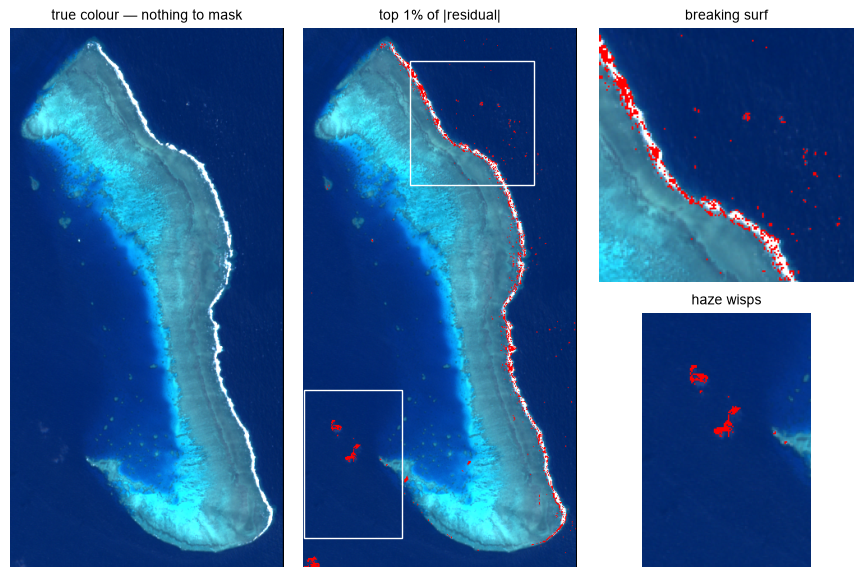

In [8]:
clear = np.load("../data/reef_clear.npy").astype(np.float32) / 10000.0
clear_pixels = clear.reshape(-1, clear.shape[2])

surf_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.3, n_jobs=-1)
surf_model.fit(clear_pixels[:, PENETRATING], clear_pixels[:, INFRARED].mean(axis=1))
residual = (clear_pixels[:, INFRARED].mean(axis=1)
            - surf_model.predict(clear_pixels[:, PENETRATING])).reshape(clear.shape[:2])

anomalous = np.abs(residual) > np.percentile(np.abs(residual), 99)
clear_rgb = stretch(clear[:, :, [RED, GREEN, BLUE]])
overlay = clear_rgb.copy()
overlay[anomalous] = [1, 0, 0]

surf_box = (slice(40, 190), slice(130, 280))     # windward crest
haze_box = (slice(440, 620), slice(0, 120))      # deep water, south-west

fig = plt.figure(figsize=(11, 7))
grid = fig.add_gridspec(2, 3, width_ratios=[1.05, 1.05, 1], wspace=0.05, hspace=0.12)
a = fig.add_subplot(grid[:, 0])
b = fig.add_subplot(grid[:, 1])
zooms = [fig.add_subplot(grid[0, 2]), fig.add_subplot(grid[1, 2])]

a.imshow(clear_rgb)
a.set_title("true colour — nothing to mask")
b.imshow(overlay)
b.set_title("top 1% of |residual|")
for z, box, name in zip(zooms, (surf_box, haze_box), ("breaking surf", "haze wisps")):
    b.add_patch(Rectangle((box[1].start, box[0].start), box[1].stop - box[1].start,
                          box[0].stop - box[0].start, fill=False, edgecolor="white", lw=1))
    z.imshow(overlay[box])
    z.set_title(name)
for ax in (a, b, *zooms):
    ax.axis("off")
plt.show()


## Transferability

Because the relationship is a property of water rather than of a sensor, a model fitted
this way transfers, measured in
[the paper this repository accompanies](https://www.mdpi.com/2072-4292/17/7/1244):
trained on 3.15 million Sentinel-2 spectra, the same approach ran
unmodified on PlanetScope at 2.5 m and on Landsat: MAE 35 DN on held-out Sentinel-2
pixels, rising to 124 DN on a geographically separate region, larger, but still tracking
the relationship rather than falling apart. Fitting to a single image, as here, is the
compact version of the idea; fitting once to an archive and reusing the model is the full idea

## Limitations

**The threshold.** 0.03 is hand-set. It is one number, against the many rules of a
conventional cloud screening method.

**Sun glint.** Specular reflection of the sun off the sea surface is bright in the
visible *and* the infrared, so the index masks glinted pixels as not-water. That protects
the downstream statistics, but on a badly glinted acquisition it can throw away much of
the scene, screening those out at the archive level
([notebook 01](01_pca_image_selection.ipynb)) is cheaper than trying to correct them.

**Cloud shadow.** Shadow is not bright in the infrared, so it is not caught here at all.
It survives the mask looking like clear, slightly darker water.

**Error propagation.** Everything downstream inherits this mask. Cloud that survives here
corrupts any deep-water reference or threshold computed from the image afterwards, and
that corruption is invisible by the time it shows up in a classification.